# Low-Inertia Frequency Stability

As inverter-based resources displace synchronous generators, the total
rotational inertia of a power system declines. Since inverter-based
resources do not inherently contribute inertial response, the system
frequency becomes increasingly sensitive to generation-load imbalances.
Two metrics characterize this degradation: the rate of change of frequency
(RoCoF) immediately following a disturbance, and the frequency nadir, the
minimum frequency reached before governor action arrests the decline.

This notebook quantifies the relationship between system inertia and
frequency stability on the IEEE 14-bus system (5 GENROU generators with
AVR and governor controls) by:

1. Scaling the inertia constants of all generators by a factor
   $\alpha$ to emulate progressive renewable penetration.
2. Tripping the largest generator at each inertia level and recording
   the rotor speed transient.
3. Computing the center-of-inertia (COI) frequency and comparing
   RoCoF and nadir across scenarios.

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

## System Setup

The IEEE 14-bus system contains five GENROU synchronous generators equipped
with AVR exciters and turbine governors. The presence of these controllers
produces well-damped transient responses that clearly illustrate the effect
of inertia on frequency dynamics.

In [3]:
case_path = andes.get_case("ieee14/ieee14_full.xlsx")
ss_ref = andes.load(case_path)
ss_ref.PFlow.run()

gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)
M_base = ss_ref.GENROU.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
gen_info.sort_values("M", ascending=False)

,gen_idx,bus,M
1,GENROU_2,2,13.0
3,GENROU_4,6,10.0
2,GENROU_3,3,10.0
4,GENROU_5,8,10.0
0,GENROU_1,1,8.0


## Frequency Response Under Varying Inertia

The largest generator by inertia is tripped at $t = 1$ s using a `Toggle`
device. Seven inertia scaling factors from $\alpha = 1.0$ down to
$\alpha = 0.15$ are simulated. The inertia constant $M$ of every generator
is scaled by $\alpha$ before each time-domain run.

In [4]:
trip_idx = gen_idxs[int(np.argmax(M_base))]

inertia_scales = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15]
results = {}

for alpha in inertia_scales:
    ss = andes.load(case_path, setup=False)
    ss.add("Toggle", model="GENROU", dev=trip_idx, t=1.0)
    ss.setup()
    ss.config.warn_abnormal = 0
    ss.GENROU.M.v[:] = M_base * alpha

    ss.PFlow.run()
    ss.TDS.config.tf = 8
    ss.TDS.config.no_tqdm = 1
    ss.TDS.run()

    results[alpha] = ss.TDS.get_timeseries(ss.GENROU.omega)

## COI Frequency After Generator Trip

The center-of-inertia (COI) frequency is computed as the inertia-weighted
average of all generator rotor speeds:

$$f_\mathrm{COI} = \left(\sum_i \frac{M_i}{\sum_j M_j}\,\omega_i\right) \times 60 \;\text{Hz}$$

Since the swing equation relates $M_i\,d\omega_i/dt$ to the power imbalance
at each machine, the COI frequency directly reflects the aggregate
generation-load mismatch following the disturbance.

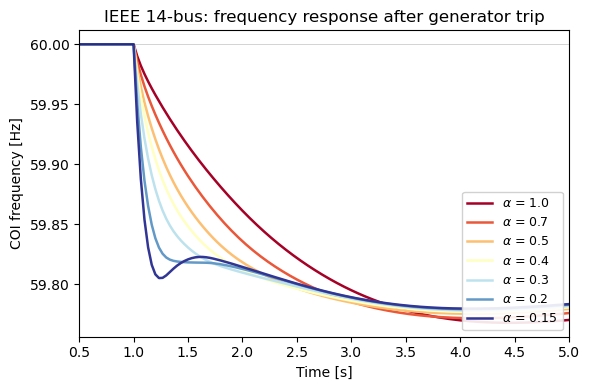

In [10]:
weights = M_base / M_base.sum()
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, (alpha, omega_df) in enumerate(results.items()):
    f_coi = (omega_df.values * weights).sum(axis=1) * 60
    color = cmap(i / (len(results) - 1))
    ax.plot(omega_df.index, f_coi, color=color, linewidth=1.8,
            label=f"$\\alpha$ = {alpha}")

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("IEEE 14-bus: frequency response after generator trip")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.5, 5.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

As the inertia scaling factor decreases from blue ($\alpha = 1.0$) to red
($\alpha = 0.15$), the initial rate of frequency decline steepens
progressively. The curves fan out clearly in the first two seconds
following the disturbance, and the well-damped oscillations produced by the
AVR and governor controls confirm that the transient is dominated by the
inertial response rather than by sustained electromechanical modes.

## Quantitative Metrics

The RoCoF is estimated as the maximum absolute rate of frequency change
within the first second after the disturbance. The nadir is the minimum
COI frequency reached before governor action arrests the decline.

In [6]:
metrics = []
for alpha, omega_df in results.items():
    f_coi = (omega_df.values * weights).sum(axis=1) * 60
    t = omega_df.index.values

    nadir = f_coi[t > 1.0].min()

    post = (t >= 1.0) & (t <= 2.0)
    t_post, f_post = t[post], f_coi[post]
    rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

    metrics.append({"α": alpha, "Nadir [Hz]": nadir, "RoCoF [Hz/s]": rocof})

metrics_df = pd.DataFrame(metrics).set_index("α")
metrics_df

,Nadir [Hz],RoCoF [Hz/s]
α,,
1.00,59.767679,0.297080
0.70,59.771490,0.423739
0.50,59.775179,0.592006
0.40,59.776735,0.738667
0.30,59.777930,0.981922
0.20,59.778977,1.464048
0.15,59.779485,1.940406


## RoCoF vs. Inertia Level

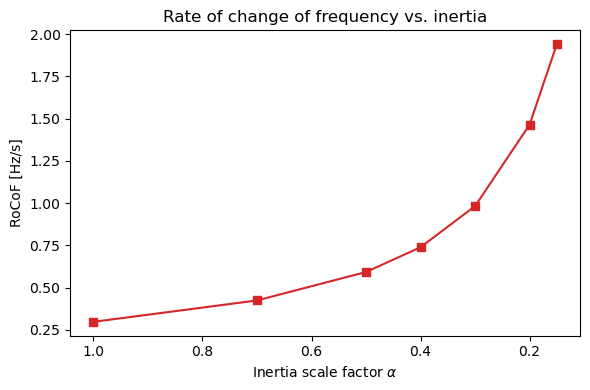

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(metrics_df.index, metrics_df["RoCoF [Hz/s]"], "s-", color="tab:red",
        markersize=6)
ax.set_xlabel("Inertia scale factor $\\alpha$")
ax.set_ylabel("RoCoF [Hz/s]")
ax.set_title("Rate of change of frequency vs. inertia")
ax.invert_xaxis()

plt.tight_layout()

Reducing the system inertia monotonically increases the RoCoF following the
generator trip. From $\alpha = 1.0$ to $\alpha = 0.15$, the RoCoF increases
by approximately six times. Although the IEEE 14-bus system is small, the
same qualitative behavior applies to larger interconnections: as synchronous
generation is displaced by inverter-based resources without synthetic inertia,
the system frequency becomes increasingly vulnerable to sudden imbalances.

## Extend This Example

- **Add synthetic inertia**: install IBR models with frequency-watt
  droop (via REECA1) and compare the RoCoF improvement at low $\alpha$.
- **Vary the contingency size**: trip different generators to study how
  disturbance magnitude interacts with inertia levels.
- **Sweep inertia continuously**: use a finer grid of $\alpha$ values to
  trace the RoCoF curve more precisely.
- **Add UFLS relays**: implement under-frequency load shedding and observe
  the threshold at which it is triggered as inertia decreases.

In [8]:
!andes misc -C

"/home/hcui9/repos/andes/docs/source/gallery/ieee14_full_out.npz" removed.
"/home/hcui9/repos/andes/docs/source/gallery/ieee14_full_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/gallery/ieee14_full_out.txt" removed.
